In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/csiro-biomass/sample_submission.csv
/kaggle/input/csiro-biomass/train.csv
/kaggle/input/csiro-biomass/test.csv
/kaggle/input/csiro-biomass/test/ID1001187975.jpg
/kaggle/input/csiro-biomass/train/ID2099464826.jpg
/kaggle/input/csiro-biomass/train/ID2037861084.jpg
/kaggle/input/csiro-biomass/train/ID1211362607.jpg
/kaggle/input/csiro-biomass/train/ID1853508321.jpg
/kaggle/input/csiro-biomass/train/ID193102215.jpg
/kaggle/input/csiro-biomass/train/ID698608346.jpg
/kaggle/input/csiro-biomass/train/ID1859251563.jpg
/kaggle/input/csiro-biomass/train/ID1880764911.jpg
/kaggle/input/csiro-biomass/train/ID853954911.jpg
/kaggle/input/csiro-biomass/train/ID1403107574.jpg
/kaggle/input/csiro-biomass/train/ID1781353117.jpg
/kaggle/input/csiro-biomass/train/ID384648061.jpg
/kaggle/input/csiro-biomass/train/ID1563418511.jpg
/kaggle/input/csiro-biomass/train/ID2125100696.jpg
/kaggle/input/csiro-biomass/train/ID482555369.jpg
/kaggle/input/csiro-biomass/train/ID638711343.jpg
/kaggle/input/c

In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.18.0
Num GPUs Available:  2


In [4]:
# 1. Load Data
df = pd.read_csv("/kaggle/input/csiro-biomass/train.csv")

# 2. Pivot Data to Wide Format (One row per image, 5 target columns)
# We need to pivot on 'image_path' (or sample_id) and 'target_name'
pivot_df = df.pivot_table(index='image_path', columns='target_name', values='target').reset_index()

# Ensure columns are in a consistent order
target_cols = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
pivot_df = pivot_df[['image_path'] + target_cols]

# Fill NaNs if any (though dataset seems complete, good practice)
pivot_df[target_cols] = pivot_df[target_cols].fillna(0.0)

print("Pivoted Shape:", pivot_df.shape)
display(pivot_df.head())

Pivoted Shape: (357, 6)


target_name,image_path,Dry_Green_g,Dry_Dead_g,Dry_Clover_g,GDM_g,Dry_Total_g
0,train/ID1011485656.jpg,16.2751,31.9984,0.0000,16.2750,48.2735
1,train/ID1012260530.jpg,7.6000,0.0000,0.0000,7.6000,7.6000
2,train/ID1025234388.jpg,0.0000,0.0000,6.0500,6.0500,6.0500
3,train/ID1028611175.jpg,24.2376,30.9703,0.0000,24.2376,55.2079
4,train/ID1035947949.jpg,10.5261,23.2239,0.4343,10.9605,34.1844


In [6]:
# 3. Split Data
train_df, val_df = train_test_split(pivot_df, test_size=0.2, random_state=42)

print("Train images:", len(train_df))
print("Val images:", len(val_df))

Train images: 285
Val images: 72


In [11]:
# 4. Create TensorFlow Dataset
IMG_SIZE = 512
BATCH_SIZE = 8

def load_image(path):
    # Load and preprocess image
    img = tf.io.read_file("/kaggle/input/csiro-biomass/" + path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def create_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    # Inputs: Image paths
    image_paths = dataframe['image_path'].values
    
    # Outputs: 5 Target values
    targets = dataframe[target_cols].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((image_paths, targets))
    
    def map_func(path, target):
        return load_image(path), target
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
        
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

# Verify shapes
for img_batch, target_batch in train_ds.take(1):
    print("Image batch shape:", img_batch.shape)
    print("Target batch shape:", target_batch.shape)
    print("Sample targets:", target_batch[0].numpy())

Image batch shape: (8, 512, 512, 3)
Target batch shape: (8, 5)
Sample targets: [ 3.0787  0.     20.6513 23.73   23.73  ]


In [12]:
for image, targets in train_ds.take(1):
    print(targets)

tf.Tensor(
[[ 6.9746 12.6079  0.      6.9746 19.5825]
 [12.5     5.5     0.2    12.7    18.2   ]
 [26.6001 36.581   0.     26.6    63.1811]
 [17.3333  1.8667  2.4    19.7333 21.6   ]
 [ 0.      0.     32.64   32.64   32.64  ]
 [39.8357  3.6214  7.2429 47.0786 50.7   ]
 [20.3265 10.5572  1.7333 22.0598 32.6169]
 [ 3.788  12.3111 35.0394 38.8275 51.1386]], shape=(8, 5), dtype=float32)


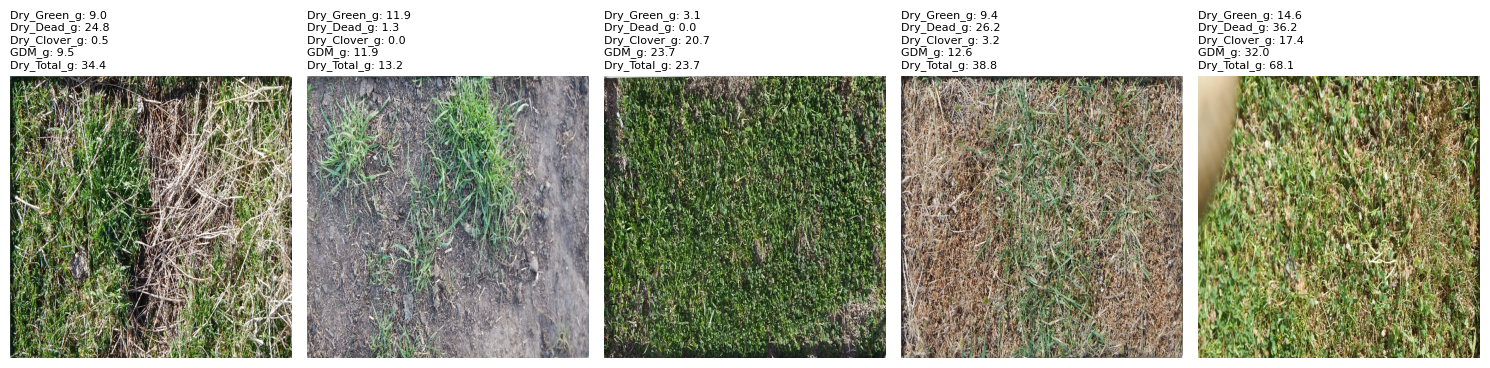

In [13]:
import matplotlib.pyplot as plt

target_names = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']

plt.figure(figsize=(15, 5))
for images, targets in train_ds.take(1):
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy())
        
        # Create a string for the targets
        t = targets[i].numpy()
        title_str = "\n".join([f"{n}: {v:.1f}" for n, v in zip(target_names, t)])
        
        plt.title(title_str, fontsize=8, loc='left')
        plt.axis("off")
plt.tight_layout()
plt.show()

In [25]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, SeparableConv2D, BatchNormalization, ReLU, Add,
    GlobalAveragePooling2D, Dense, Dropout, Input, Multiply, Reshape
)
from tensorflow.keras.models import Model

# ---------- HELPERS ----------

def conv_bn_relu(x, filters, kernel=3, stride=1):
    x = Conv2D(filters, kernel, strides=stride, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    return ReLU()(x)

def depthwise_block(x, filters, stride=1):
    x = SeparableConv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    return ReLU()(x)

def squeeze_excitation(x, reduction=16):
    f = x.shape[-1]
    se = GlobalAveragePooling2D()(x)
    se = Dense(f // reduction, activation="relu")(se)
    se = Dense(f, activation="sigmoid")(se)
    se = Reshape((1, 1, f))(se)
    return Multiply()([x, se])

def residual_block(x, filters, stride=1):
    shortcut = x

    x = depthwise_block(x, filters, stride=stride)
    x = depthwise_block(x, filters)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    return ReLU()(x)

# ---------- FINAL MODEL ----------

def build_expanded_model(img_size=512):
    inputs = Input(shape=(img_size, img_size, 3))

    # Stem
    x = conv_bn_relu(inputs, 32, stride=2)
    x = residual_block(x, 32)

    # Stage 1 (2 residual blocks)
    x = conv_bn_relu(x, 64)
    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)
    x = squeeze_excitation(x)

    # Stage 2 (3 residual blocks)
    x = conv_bn_relu(x, 128)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)
    x = residual_block(x, 128)
    x = squeeze_excitation(x)

    # Stage 3 (3 residual blocks)
    x = conv_bn_relu(x, 256)
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)
    x = residual_block(x, 256)
    x = squeeze_excitation(x)

    # Stage 4 (2 deep blocks + final SE)
    x = conv_bn_relu(x, 512)
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)
    x = squeeze_excitation(x)

    # Head
    x = GlobalAveragePooling2D()(x)

    x = Dense(768, activation="relu")(x)
    x = Dropout(0.25)(x)

    x = Dense(512, activation="relu")(x)
    x = Dropout(0.2)(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.15)(x)

    x = Dense(128, activation="relu")(x)

    outputs = Dense(5)(x)

    return Model(inputs, outputs)


model = build_expanded_model(IMG_SIZE)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_42 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_20 │ (None, 256, 256,  │      1,312 │ re_lu_42[0][0]    │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_43 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_21 │ (None, 256, 256,  │      1,312 │ re_lu_43[0][0]    │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_44 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 256, 256,  │          0 │ re_lu_44[0][0],   │
│                     │ 32)               │            │ re_lu_42[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_45 (ReLU)     │ (None, 256, 256,  │          0 │ add_10[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 256, 256,  │     18,432 │ re_lu_45[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_46 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_22 │ (None, 128, 128,  │      4,672 │ re_lu_46[0][0]    │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ separable_conv2d

 Total params: 4,539,937 (17.32 MB)

 Trainable params: 4,526,689 (17.27 MB)

 Non-trainable params: 13,248 (51.75 KB)

In [26]:
import tensorflow.keras.backend as K

def weighted_r2(y_true, y_pred):
    # Weights for the 5 biomass components
    # Dry_Green_g, Dry_Dead_g, Dry_Clover_g, GDM_g, Dry_Total_g
    weights = tf.constant([0.1, 0.1, 0.1, 0.2, 0.5], dtype=tf.float32)
    
    # Total Sum of Squares (TSS)
    mean_y_true = K.mean(y_true, axis=0)
    tss = K.sum(K.square(y_true - mean_y_true), axis=0)
    
    # Residual Sum of Squares (RSS)
    rss = K.sum(K.square(y_true - y_pred), axis=0)
    
    # R2 for each component: 1 - (RSS / (TSS + epsilon))
    # Adding epsilon to avoid division by zero
    r2_scores = 1 - (rss / (tss + K.epsilon()))
    
    # Weighted Average R2
    weighted_r2_score = K.sum(r2_scores * weights)
    
    return weighted_r2_score

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae', weighted_r2]
)


In [27]:
# Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras', 
    monitor='val_weighted_r2', 
    mode='max', 
    save_best_only=True, 
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_weighted_r2', 
    mode='max', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6,
    verbose=1
)

# Train for full 200 epochs, regardless of metric stagnation
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=70,
    callbacks=[checkpoint, reduce_lr],
    verbose=1
)


Epoch 1/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - loss: 1356.6398 - mae: 25.0105 - weighted_r2: -2.7418
Epoch 1: val_weighted_r2 improved from -inf to -3.39407, saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 693ms/step - loss: 1351.6260 - mae: 24.9550 - weighted_r2: -2.7324 - val_loss: 1060.6400 - val_mae: 23.1755 - val_weighted_r2: -3.3941 - learning_rate: 1.0000e-04
Epoch 2/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 576.4218 - mae: 15.8481 - weighted_r2: -1.3580
Epoch 2: val_weighted_r2 improved from -3.39407 to -2.51427, saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - loss: 575.5367 - mae: 15.8413 - weighted_r2: -1.3580 - val_loss: 891.9558 - val_mae: 20.5898 - val_weighted_r2: -2.5143 - learning_rate: 1.0000e-04
Epoch 3/70
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 381.4016 - mae: 13.8829 - weighted_r2: -0.4990
Epoch 3: val_weighted_r2 improved from -2.51427 to -2.27562, saving model to best_model.keras
36/36 ━━━━━━━━

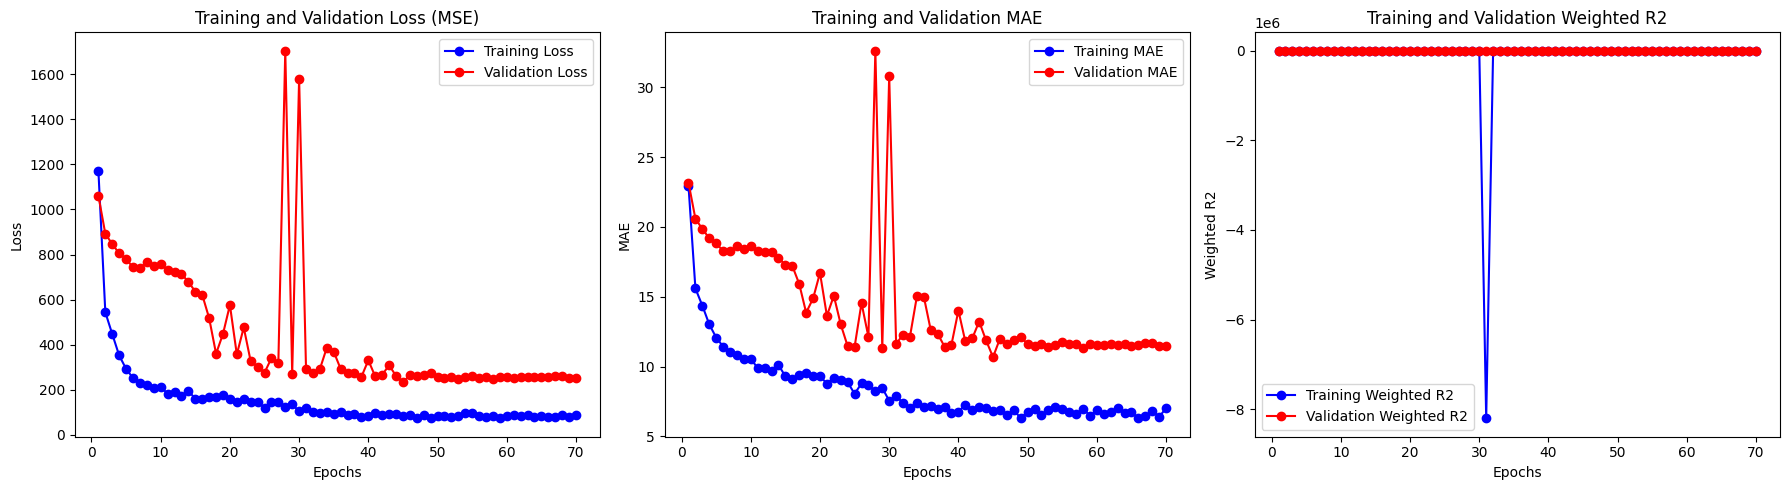

In [37]:
import matplotlib.pyplot as plt

def plot_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    r2 = history.history['weighted_r2']
    val_r2 = history.history['val_weighted_r2']
    
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(18, 5))
    
    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot MAE
    plt.subplot(1, 3, 2)
    plt.plot(epochs, mae, 'bo-', label='Training MAE')
    plt.plot(epochs, val_mae, 'ro-', label='Validation MAE')
    plt.title('Training and Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    
    # Plot Weighted R2
    plt.subplot(1, 3, 3)
    plt.plot(epochs, r2, 'bo-', label='Training Weighted R2')
    plt.plot(epochs, val_r2, 'ro-', label='Validation Weighted R2')
    plt.title('Training and Validation Weighted R2')
    plt.xlabel('Epochs')
    plt.ylabel('Weighted R2')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)


In [30]:
model.save("model.keras")

Generating predictions for validation set...

Overall Weighted R2 Score: 0.3069
Component R2 Scores:
  Dry_Green_g    : 0.2579
  Dry_Dead_g     : 0.0892
  Dry_Clover_g   : 0.3503
  GDM_g          : 0.4506
  Dry_Total_g    : 0.2941

Visualizing 5 random samples...


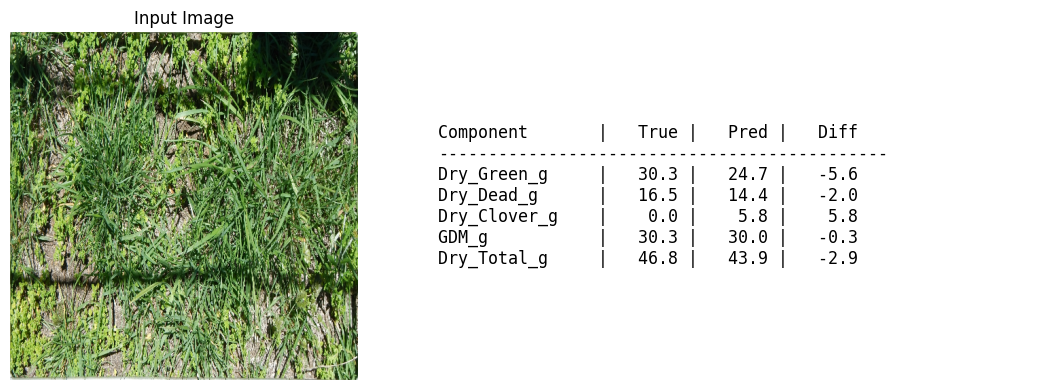

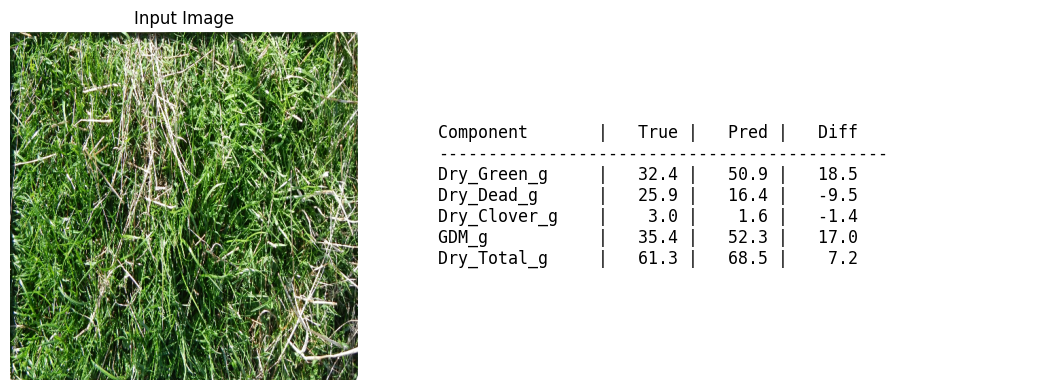

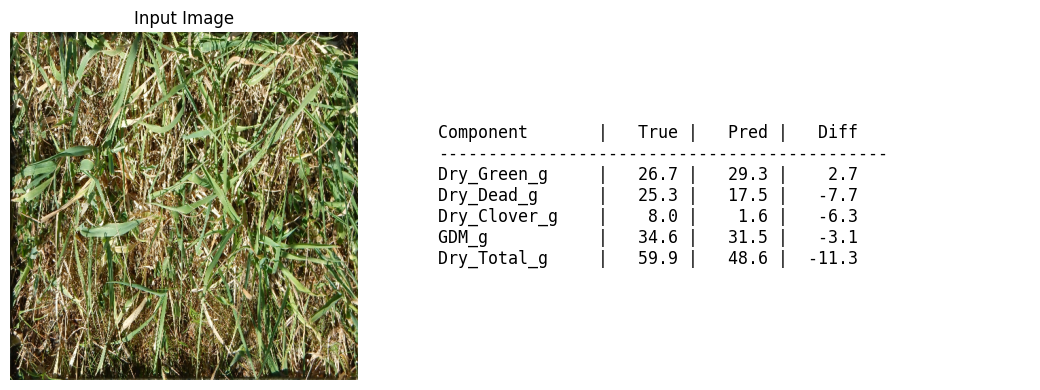

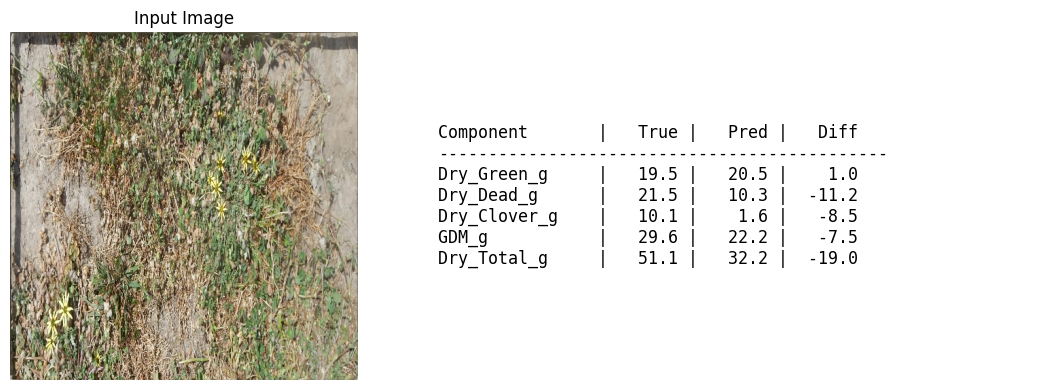

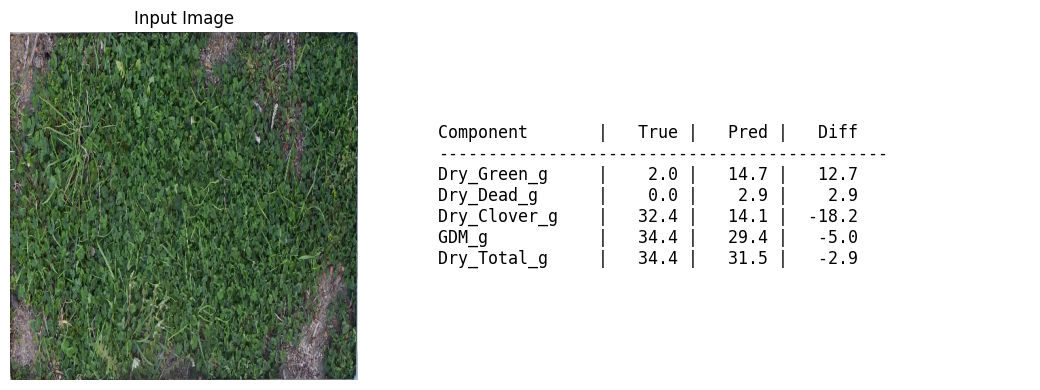

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_and_visualize(model, val_ds, num_samples=5):
    # 1. Get all predictions and true values
    all_images = []
    all_targets = []
    all_preds = []
    
    print("Generating predictions for validation set...")
    # Unbatch the dataset to process all samples
    for images, targets in val_ds:
        preds = model.predict(images, verbose=0)
        all_images.append(images.numpy())
        all_targets.append(targets.numpy())
        all_preds.append(preds)
        
    # Concatenate batches
    all_images = np.concatenate(all_images, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    
    # 2. Calculate Overall Weighted R2
    weights = np.array([0.1, 0.1, 0.1, 0.2, 0.5])
    
    mean_true = np.mean(all_targets, axis=0)
    tss = np.sum((all_targets - mean_true)**2, axis=0)
    rss = np.sum((all_targets - all_preds)**2, axis=0)
    
    # Avoid division by zero
    r2_scores = 1 - (rss / (tss + 1e-7))
    weighted_r2 = np.sum(r2_scores * weights)
    
    print(f"\nOverall Weighted R2 Score: {weighted_r2:.4f}")
    print(f"Component R2 Scores:")
    target_names = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    for name, score in zip(target_names, r2_scores):
        print(f"  {name:<15}: {score:.4f}")
        
    # 3. Visualize Samples
    print(f"\nVisualizing {num_samples} random samples...")
    indices = np.random.choice(len(all_images), num_samples, replace=False)
    
    for idx in indices:
        img = all_images[idx]
        true = all_targets[idx]
        pred = all_preds[idx]
        
        plt.figure(figsize=(12, 4))
        
        # Image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Input Image")
        
        # Table of values
        plt.subplot(1, 2, 2)
        plt.axis('off')
        
        # Header
        text_str = f"{'Component':<15} | {'True':>6} | {'Pred':>6} | {'Diff':>6}\n"
        text_str += "-"*45 + "\n"
        
        # Rows
        for i, name in enumerate(target_names):
            diff = pred[i] - true[i]
            text_str += f"{name:<15} | {true[i]:6.1f} | {pred[i]:6.1f} | {diff:6.1f}\n"
            
        plt.text(0, 0.5, text_str, fontsize=12, family='monospace', va='center')
        plt.tight_layout()
        plt.show()

# Run evaluation
evaluate_and_visualize(model, val_ds)


In [34]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os

def generate_submission(model):
    print("Loading test data...")
    test_df = pd.read_csv("/kaggle/input/csiro-biomass/test.csv")
    
    # Get unique images to predict on
    unique_images = test_df['image_path'].unique()
    print(f"Found {len(unique_images)} unique test images.")
    
    # Create Dataset
    def load_image(path):
        # Check if path exists
        full_path = "/kaggle/input/csiro-biomass/" + path
        img = tf.io.read_file(full_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0
        return img

    test_ds = tf.data.Dataset.from_tensor_slices(unique_images)
    test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    print("Predicting...")
    # Predict
    predictions = model.predict(test_ds, verbose=1)
    
    # Map predictions to image paths
    # predictions shape: (N_images, 5)
    # Target order: ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    target_cols = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    
    # Create a lookup dictionary: image_path -> {target_name: value}
    pred_dict = {}
    for img_path, pred_row in zip(unique_images, predictions):
        pred_dict[img_path] = {col: val for col, val in zip(target_cols, pred_row)}
        
    print("Formatting submission...")
    # Create submission rows
    submission_rows = []
    for index, row in test_df.iterrows():
        img_path = row['image_path']
        target_name = row['target_name']
        sample_id = row['sample_id']
        
        # Get prediction
        if img_path in pred_dict:
            pred_value = pred_dict[img_path][target_name]
        else:
            # Fallback if something went wrong (shouldn't happen)
            pred_value = 0.0
        
        # Ensure non-negative (biomass can't be negative)
        pred_value = max(0.0, pred_value)
        
        submission_rows.append({'sample_id': sample_id, 'target': pred_value})
        
    submission_df = pd.DataFrame(submission_rows)
    
    # Save to CSV
    output_file = "submission.csv"
    submission_df.to_csv(output_file, index=False)
    print(f"Saved submission to {output_file}")
    
    # Print the content for user to copy if needed
    print("\n" + "="*20 + " SUBMISSION CSV CONTENT " + "="*20)
    print(submission_df.to_csv(index=False))
    print("="*64)

# Run generation
generate_submission(model)


Loading test data...
Found 1 unique test images.
Predicting...


E0000 00:00:1763937267.222715     111 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763937267.380440     111 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763937267.527173     111 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Formatting submission...
Saved submission to submission.csv

==================== SUBMISSION CSV CONTENT ====================
sample_id,target
ID1001187975__Dry_Clover_g,0.69307905
ID1001187975__Dry_Dead_g,17.505985
ID1001187975__Dry_Green_g,24.156559
ID1001187975__Dry_Total_g,42.46705
ID1001187975__GDM_g,25.176622

